Remember to `pip install -r requirements.txt`

In [2]:
import os

os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import keras
from keras import layers

In [3]:
# Generate data in [-1, 1] range
np.random.seed(42)
n = 500

X = (np.random.rand(n, 2) * 2 - 1).astype('float32')  # uniform [-1, 1]
y = ((X[:, 0] * X[:, 1]) > 0).astype('int32')  # 1 if same sign (both + or both -)

In [4]:
# Model: 2 outputs with softmax
model = keras.Sequential([
    layers.Input(shape=(2,), name='przeInput'),
    layers.Dense(4, activation='tanh', name='hidden1'),
    layers.Dense(2, activation='softmax', name='przeOutput')
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X, y, epochs=200, batch_size=50, verbose=0)
# Quick summary
loss, acc = model.evaluate(X, y, verbose=0)
print(f"Accuracy: {acc:.1%}")

Accuracy: 99.4%


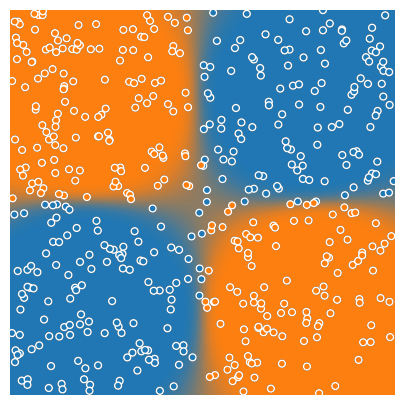

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Predict across the whole [-1, 1] grid for the background color
xx, yy = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype('float32')
probs = model.predict(grid, verbose=0)[:, 1].reshape(xx.shape)

# Plot
cmap = LinearSegmentedColormap.from_list('playground', ['#ff7f0e', '#1f77b4'])

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, probs, levels=50, cmap=cmap, vmin=0, vmax=1)
plt.scatter(X[:, 0], X[:, 1], c=['white']*n, edgecolors='black', linewidths=0.5, s=30)  # dots
plt.scatter(X[:, 0], X[:, 1], c=['#ff7f0e' if c == 0 else '#1f77b4' for c in y], edgecolors='white', s=25)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal')
plt.axis('off')
plt.show()

In [7]:
import hls4ml

print('compiling to vhdl...')

config = hls4ml.utils.config_from_keras_model(model)

config['Backend'] = 'Vitis'
config['Part'] = 'xc7a35ticsg324-1L' # Artix-7
config['ClockPeriod'] = 10
config['IOType'] = 'io_parallel'
print(config)

hls_dir = './methylphenidate_vivado/methylphenidate_vivado.srcs/sources_1/new/medikinet'
hls_model = hls4ml.converters.convert_from_keras_model(
    model=model,
    output_dir=hls_dir,
    project_name='medikinet',
    backend='Vitis',
    hls_config=config,
)
hls_model.write()

compiling to vhdl...
{'Model': {'Precision': {'default': 'fixed<16,6>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}, 'Backend': 'Vitis', 'Part': 'xc7a35ticsg324-1L', 'ClockPeriod': 10, 'IOType': 'io_parallel'}


In [9]:
hls_model.build()
hls4ml.report.read_vivado_report(hls_dir)


****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Wed May 27 11:54:17 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/matiii/dev/proj/vhdl/methylphenidate/methylphenidate_vivado/methylphenidate_vivado.srcs/sources_1/new/medikinet/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project medikinet_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Creating and opening solution '/home/matiii/dev/proj/vhdl/methylphenidate/methylphenidate_vivado/methylphenidate_vivado.srcs/sources_1/new/medikinet/medikinet_prj'.
INFO: [HLS 200-1510] Running: set_top medikinet 
INFO: [HLS 200-1510] Running: add_files firmware/medikinet.cpp -cflags -std=c++0x 
INFO: [